<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل سیزدهم: شبکه‌های عصبی</h2>
</div>

<div dir="rtl" align="right">

# مثال تکمیلی رگرسیون با شبکهٔ عصبی MLP

در این مثال، رگرسور جنگل تصادفی با یک پرسپترون چندلایه (MLP) جایگزین شده است. مدل با همان دادهٔ ده‌ردیفی `Position_Salaries.csv` برازش می‌شود و منحنی آن در کنار مقادیر مشاهده‌شده نمایش داده می‌شود.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل `Position_Salaries.csv` باید در پوشهٔ `data` در کنار پوشهٔ نوت‌بوک‌ها، یا در پوشهٔ کاری `data`، موجود باشد. کتابخانه‌های موردنیاز شامل NumPy، pandas، Matplotlib و scikit-learn هستند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("فایل Position_Salaries.csv را در پوشهٔ data قرار دهید.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## ۱. خواندن دادهٔ حقوق

`Level` سطح شغلی است و `Salary` حقوق ثبت‌شده. این مجموعه فقط ده ردیف دارد. بنابراین این مثال برای مشاهدهٔ شکل برازش آموزشی است و تقسیم تصادفی داده به آموزش و آزمون، با چنین نمونهٔ کوچکی ارزیابی قابل اتکایی نمی‌دهد.

</div>

In [2]:
# خواندن دادهٔ حقوق
data = pd.read_csv(DATA / "Position_Salaries.csv")
X = data[["Level"]].to_numpy(dtype=float)
y = data["Salary"].to_numpy(dtype=float)
grid = np.arange(float(X.min()), float(X.max()) + 0.01, 0.01).reshape(-1, 1)
display(data)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


<div dir="rtl" align="right">

## ۲. برازش رگرسور MLP

ویژگی و هدف به‌طور جداگانه استاندارد می‌شوند تا مقیاس بسیار متفاوت سطح شغلی و حقوق آموزش شبکه را دشوار نکند. پس از پیش‌بینی، خروجی به واحد اصلی حقوق برگردانده می‌شود. بذر تصادفی ثابت، نتیجهٔ تکرار اجرا را بازتولیدپذیرتر می‌کند.

</div>

In [3]:
# آموزش و ارزیابی توصیفی روی همان داده‌های برازش
regressor = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16), activation="relu", solver="lbfgs",
        alpha=0.01, max_iter=10000, random_state=42
    )
)
model = TransformedTargetRegressor(
    regressor=regressor, transformer=StandardScaler()
)
model.fit(X, y)

train_prediction = model.predict(X)
metrics = pd.DataFrame([{
    "MAE (train)": mean_absolute_error(y, train_prediction),
    "RMSE (train)": np.sqrt(mean_squared_error(y, train_prediction)),
    "R² (train)": r2_score(y, train_prediction),
}])
display(metrics.round(2))

estimate_6_5 = model.predict(np.array([[6.5]]))[0]
print(f"MLP estimate at level 6.5: {estimate_6_5:,.2f} (source salary units)")

,MAE (train),RMSE (train),R² (train)
0,2756.83,3320.68,1.0


MLP estimate at level 6.5: 171,743.59 (source salary units)


<div dir="rtl" align="right">

## ۳. نمایش منحنی برازش

نقاط، داده‌های مشاهده‌شده و خط، خروجی شبکه در بازهٔ سطوح موجود را نشان می‌دهد. برآورد سطح ۶٫۵ صرفاً خروجی همین مدل است؛ چون مقدار واقعی این سطح در فایل نیست، نمی‌توان خطای آن را محاسبه کرد.

</div>

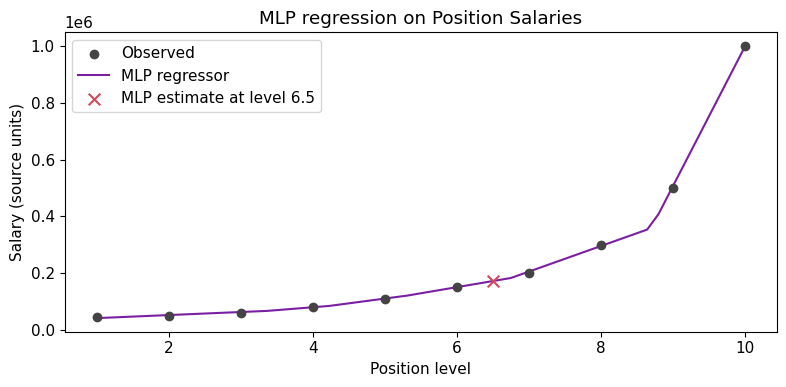

In [4]:
# نمودار MLP و داده‌های مشاهده‌شده
plt.scatter(X[:, 0], y, color="#444444", label="Observed", zorder=3)
plt.plot(grid[:, 0], model.predict(grid), color="#7b1fa2", label="MLP regressor")
plt.scatter([6.5], [estimate_6_5], color="#d1495b", marker="x", s=70,
            label="MLP estimate at level 6.5", zorder=4)
plt.xlabel("Position level")
plt.ylabel("Salary (source units)")
plt.title("MLP regression on Position Salaries")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی و محدودیت‌ها

MAE، RMSE و R² بالا در سلول قبل روی همان ده ردیفی محاسبه شده‌اند که مدل با آن‌ها آموزش دیده است؛ این‌ها معیار آزمون مستقل نیستند و نباید به‌عنوان سنجش تعمیم‌پذیری تفسیر شوند. شبکهٔ عصبی می‌تواند با تغییر معماری و تنظیمات، منحنی متفاوتی بسازد. برای مقایسهٔ معتبر با مدل‌های دیگر به دادهٔ بیشتر و ارزیابی منصفانه با روش اعتبارسنجی مناسب نیاز است.

</div>

<div dir="rtl" align="right">

## مأخذ و منابع فنی

مراجع فنی: [MLPRegressor در scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)، [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)، [pandas](https://pandas.pydata.org/docs/).

</div>